In [ ]:
from pyprojroot import here
from pdal import Writer, Filter, Reader
from man_seg_preproc.utils import run_pdal
import laspy
import numpy as np

# Tile

tile the point cloud with a grid of 10 meters.
We need tiling because semantic segmentation processing times increase exponentially with the size of the tile

In [ ]:
propagated = here("data/0_raw/propagated.las")
tile_folder = here("data/1_tiled")
tile_folder.mkdir(parents=True, exist_ok=True)

took 10mins on Cave012

In [ ]:
pipeline = (
    Reader(filename=str(propagated))
    | Filter(type="filters.splitter", length=3, buffer=.5)
    | Writer.las(filename=str(tile_folder / "tile_#.laz"), minor_version=4, forward = ["creation_doy", "creation_year", "scale_x", "scale_y", "scale_z", "offset_x", "offset_y", "offset_z"])
)

run_pdal(pipeline, pipe_name="tiling")

# N Voxels

In [ ]:
def count_voxels(tile_file, voxel_size=0.02):
    """
    Load the first tiled point cloud, voxelize at specified size, and count voxels.
    
    Args:
        tile_file: Path to a tiled LAS file
        voxel_size: Voxel size in meters (default 0.02 = 2cm)
    
    Returns:
        Number of voxels
    """

    # Read point cloud
    las = laspy.read(tile_file).xyz
    
    # Voxelize by dividing coordinates by voxel size and converting to integers
    voxel_indices = np.floor(las / voxel_size).astype(int)
    
    # Count unique voxels
    unique_voxels = np.unique(voxel_indices, axis=0)
    n_voxels = len(unique_voxels)
    
    return n_voxels

In [ ]:
from  fastcore.all import L

In [ ]:
tiles = tile_folder.ls().shuffle()[:10] # subset for sampling

In [ ]:
n_voxels = tiles.map(count_voxels)

In [ ]:
n_voxels

(#10) [5183572,2168049,621150,4066934,4193816,836793,1137606,3214538,1596361,1790]

In [ ]:
from matplotlib import pyplot as plt

(array([1., 1., 0., 1., 3., 0., 2., 0., 1., 1.]),
 array([1.590000e+02, 5.903380e+04, 1.179086e+05, 1.767834e+05,
        2.356582e+05, 2.945330e+05, 3.534078e+05, 4.122826e+05,
        4.711574e+05, 5.300322e+05, 5.889070e+05]),
 <BarContainer object of 10 artists>)

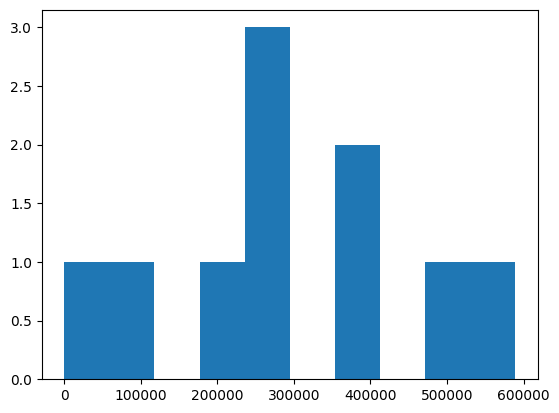

In [ ]:
plt.hist(n_voxels)